<a href="https://colab.research.google.com/github/NehirDarici/BankMarketing/blob/main/BankMarketingFinal1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# BANK MARKETING – END-TO-END DATA SCIENCE PROJECT
# Hedef: Müşterinin vadeli mevduata abone olup olmayacağını tahmin etmek
# Veri Seti: bank-full.csv  |  Problem: İkili Sınıflandırma

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["lightgbm", "xgboost", "imbalanced-learn", "scikit-learn", "shap"]:
    install(pkg)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay,precision_recall_curve, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# VERİNİN YÜKLENMESİ
!wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip

!unzip -o bank+marketing.zip

!unzip -o bank.zip

--2026-05-08 18:03:53--  https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip.2’

bank+marketing.zip.     [  <=>               ] 999.85K  2.56MB/s    in 0.4s    

2026-05-08 18:03:53 (2.56 MB/s) - ‘bank+marketing.zip.2’ saved [1023843]

Archive:  bank+marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     
Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [ ]:
df_raw = pd.read_csv('bank-full.csv', sep=';')

# Veri seti boyutunu yazdırma
print(f"Satır Sayısı: {df_raw.shape[0]}")
print(f"Sütun Sayısı: {df_raw.shape[1]}")

df_raw.head()

Satır Sayısı: 45211
Sütun Sayısı: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:

df = df_raw.copy()

# 1. Hedef Değişken Dönüşümü
df["y"] = df["y"].astype(str).str.lower().map({"yes": 1, "no": 0})

# 2. Özellik Mühendisliği (Satır bazlı matematiksel işlemler olduğu için sızıntı yapmaz)
if "campaign" in df.columns and "previous" in df.columns:
    df["contact_ratio"] = df["campaign"] / (df["previous"] + 1)
if "age" in df.columns:
    df["age_group"] = pd.cut(df["age"], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3]).astype(int)

# İSTATİSTİKSEL İŞLEMLERDEN ÖNCE VERİNİN BÖLÜNMESİ
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Bölünme Tamamlandı -> Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# SIZINTISIZ ÖN İŞLEME

# A. Eksik (unknown) Değerleri Mod ile Doldurma
unknown_columns = [col for col in X_train.columns if X_train[col].dtype == object and (X_train[col] == "unknown").any()]
for col in unknown_columns:
    most_frequent_value = X_train.loc[X_train[col] != "unknown", col].mode()[0]

    # Öğrenilen değer hem Train hem Test setine uygulanır
    X_train.loc[:, col] = X_train[col].replace("unknown", most_frequent_value)
    X_test.loc[:, col]  = X_test[col].replace("unknown", most_frequent_value)
    print(f"  {col:20s}: unknown → mode ({most_frequent_value})")

# B. Aykırı Değer (Outlier) Tıraşlaması
numeric_columns = X_train.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    # Q1 ve Q3 değerlerini SADECE Eğitim (Train) setinden hesaplanır
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hesaplanan sınırları hem Train hem Test setine uyguluyoruz
    X_train.loc[:, col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
    X_test.loc[:, col]  = X_test[col].clip(lower=lower_bound, upper=upper_bound)

# C. Kategorik Değişken Kodlaması (One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, drop_first=True)

# Test setinde olmayan (Train'de olup Test'te görülmeyen) kategorileri 0 ile doldurarak hizalıyoruz
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# D. Standartlaştırma (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded) # fit_transform sadece train'de
X_test_scaled  = scaler.transform(X_test_encoded)      # transform sadece test'te

print("\n✔ Veri Sızıntısı (Leakage) olmadan ön işleme tamamlandı!")

Bölünme Tamamlandı -> Train: 36168 | Test: 9043
  job                 : unknown → mode (blue-collar)
  education           : unknown → mode (secondary)
  contact             : unknown → mode (cellular)
  poutcome            : unknown → mode (failure)

✔ Veri Sızıntısı (Leakage) olmadan ön işleme tamamlandı!


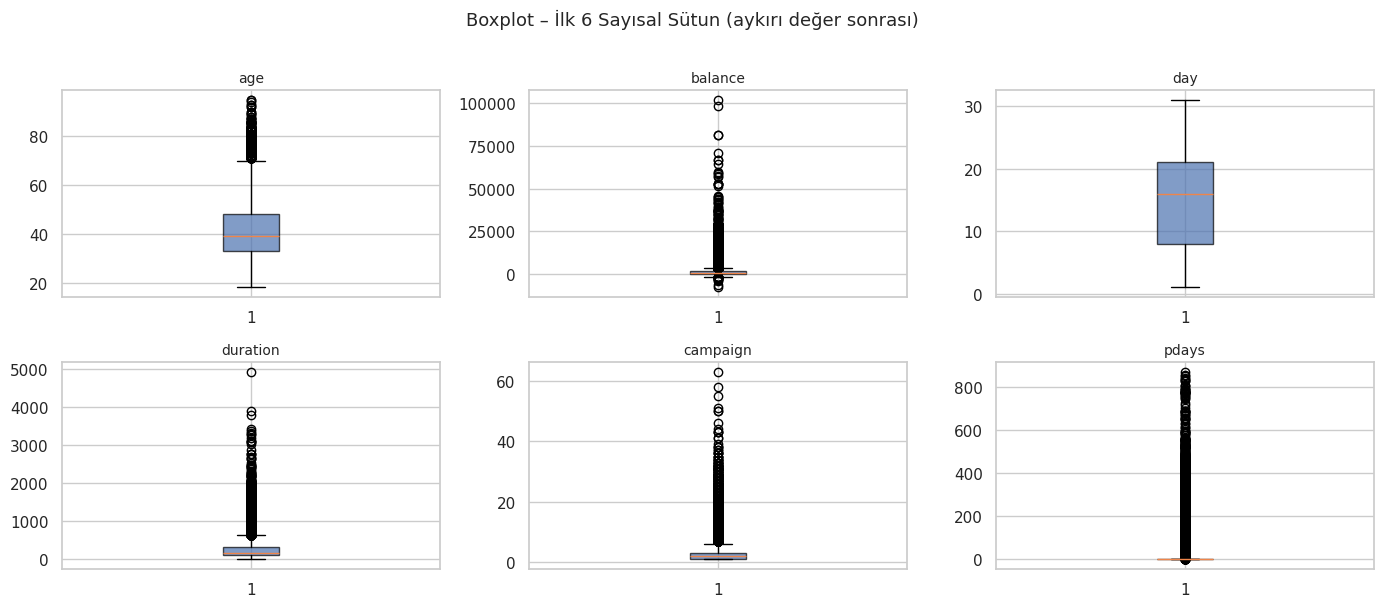

In [ ]:
# Boxplot – ilk 6 sayısal sütun
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flat, numeric_columns[:6]):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Boxplot – İlk 6 Sayısal Sütun (aykırı değer sonrası)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

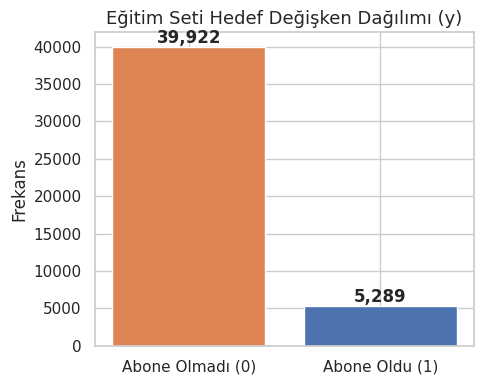

In [ ]:
#Hedef değişken dağılımı
fig, ax = plt.subplots(figsize=(5, 4))
val_counts = pd.Series(y).value_counts()
bars = ax.bar(["Abone Olmadı (0)", "Abone Oldu (1)"], val_counts.values, color=["#DD8452", "#4C72B0"])
for bar, val in zip(bars, val_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100, f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Eğitim Seti Hedef Değişken Dağılımı (y)", fontsize=13)
ax.set_ylabel("Frekans")
plt.tight_layout()
plt.show()

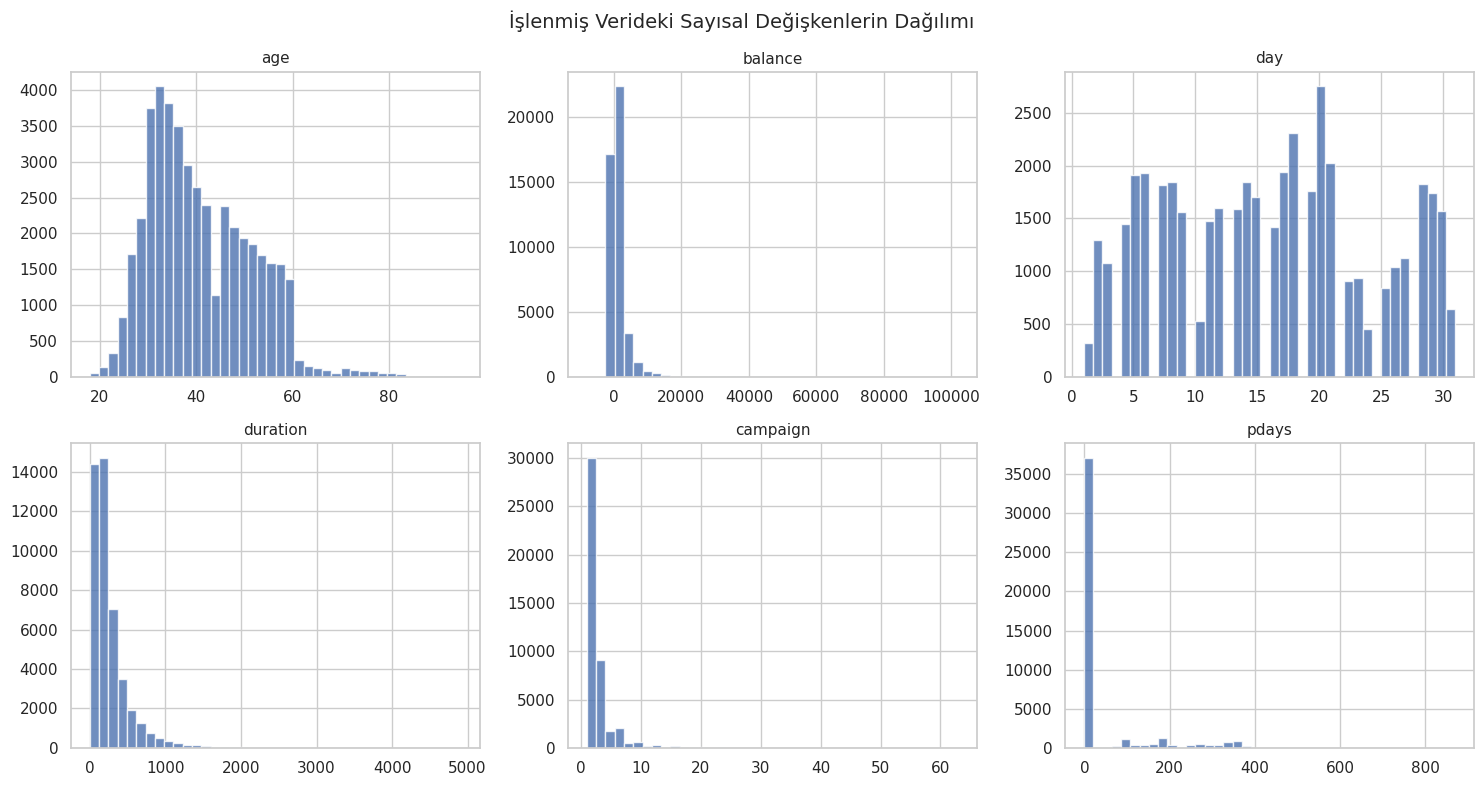

In [ ]:
#Histogramlar
num_cols_to_plot = numeric_columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols_to_plot):
    ax.hist(df[col], bins=40, color="#4C72B0", edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
plt.suptitle("İşlenmiş Verideki Sayısal Değişkenlerin Dağılımı", fontsize=14)
plt.tight_layout()
plt.show()

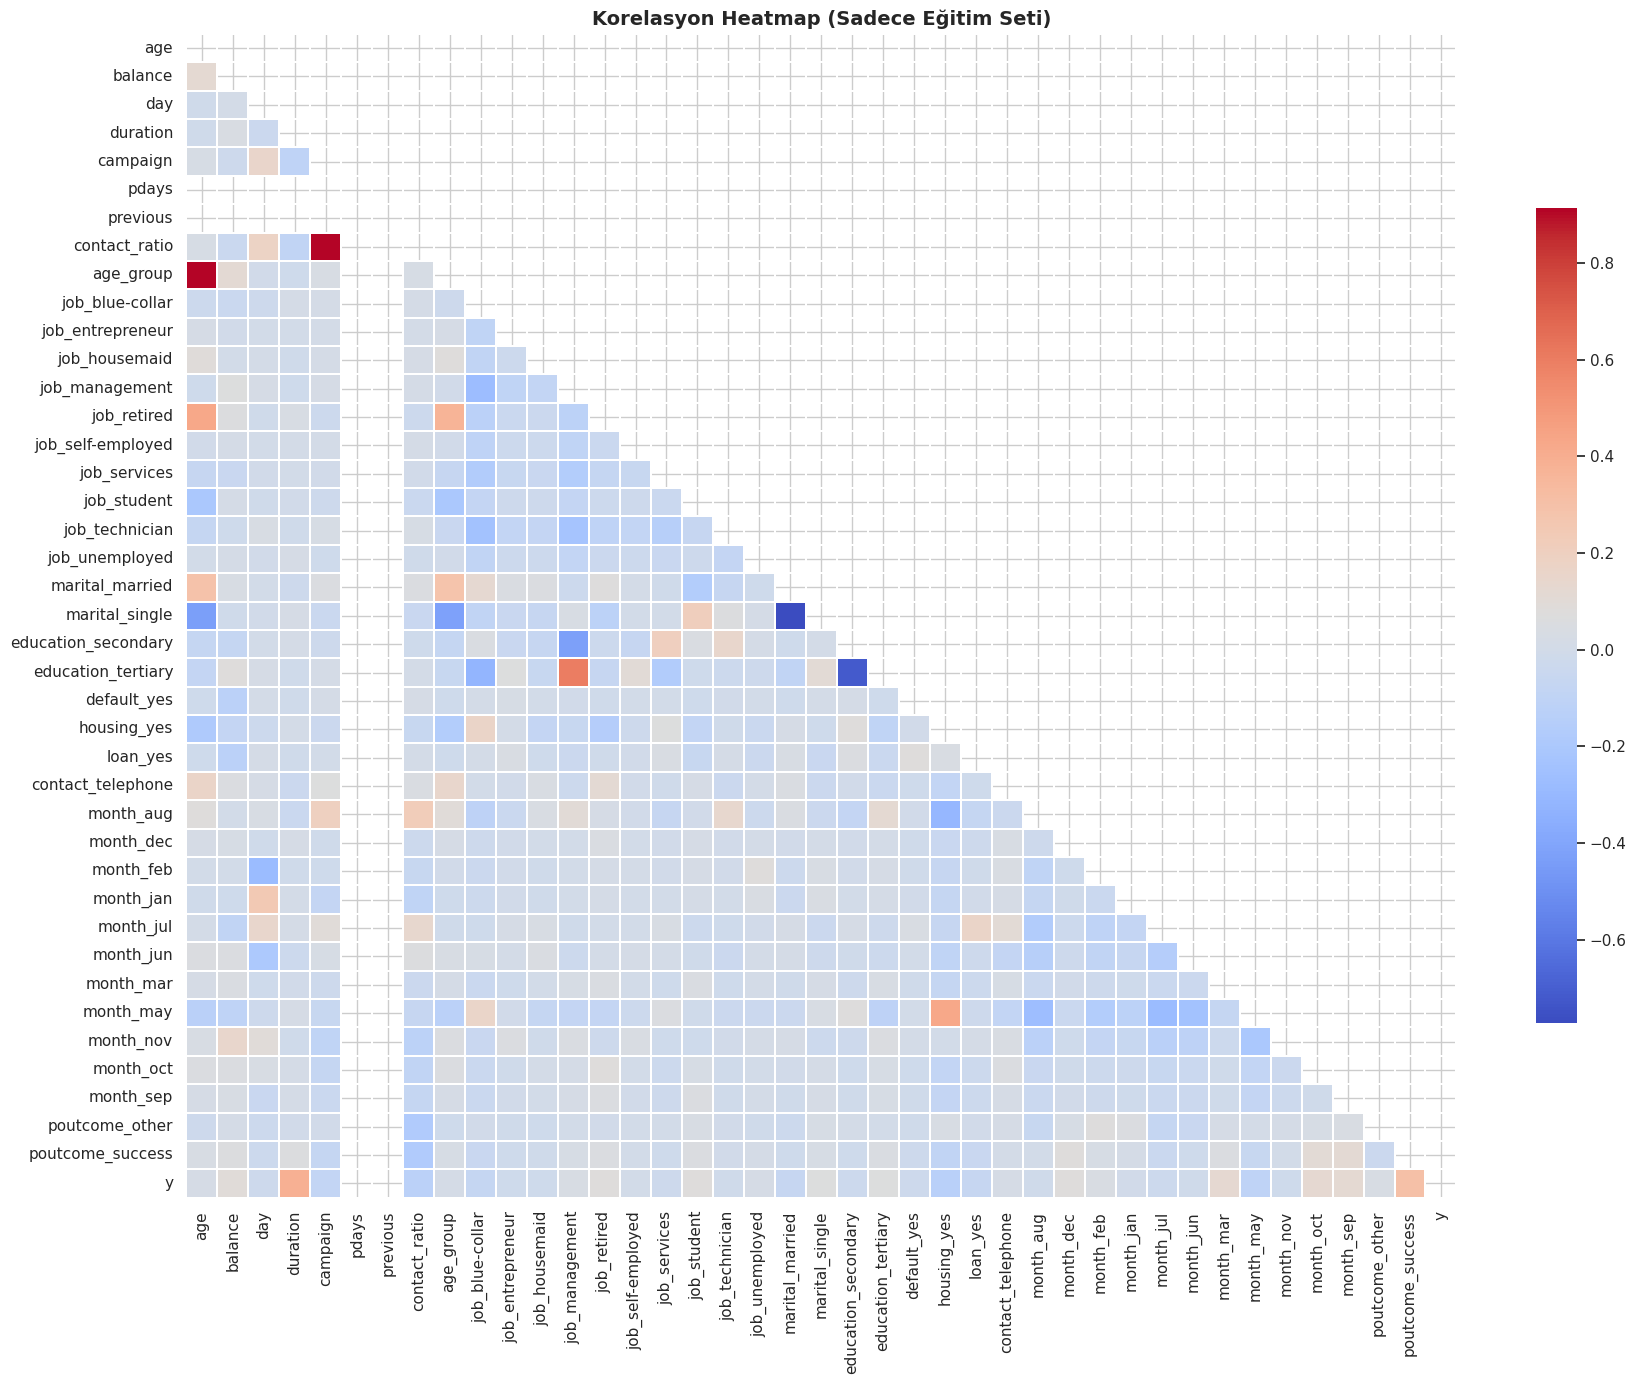

In [ ]:
# SIZINTISIZ KORELASYON ANALİZİ

# X_train_scaled bir Numpy dizisi olduğu için onu DataFrame'e çeviriyoruz.
# Sütun isimleri olarak One-Hot Encoding sonrası oluşan güncel sütunları (X_train_encoded.columns) kullanıyoruz.
corr_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)

# Hedef değişkenimiz olan y_train'i de korelasyona dahil ediyoruz.
# (Numpy dizisine dönüşürken indexler sıfırlandığı için y_train'in indexini de reset_index ile eşitliyoruz)
corr_df["y"] = y_train.reset_index(drop=True)

# Korelasyon matrisini hesapla
corr = corr_df.corr()

# Heatmap Çizimi
fig, ax = plt.subplots(figsize=(18, 14))

# Üst üçgeni gizlemek için maske oluştur (görüntü karmaşasını azaltır)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.7}
)

ax.set_title("Korelasyon Heatmap (Sadece Eğitim Seti)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# --- 1. VERİ SIZINTISINI ÖNLEME: ÖNCE BÖLME İŞLEMİ ---
# Özellikleri (X_raw) ve Hedef Değişkeni (y) belirleme
X_raw = df.drop("y", axis=1)
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# --- 2. SIZINTISIZ ÖN İŞLEME (Kategorik ve Sayısal Değişkenler İçin) ---
# A. Eksik (unknown) Değerleri Doldurma
unknown_columns = [col for col in X_train.columns if X_train[col].dtype == object and (X_train[col] == "unknown").any()]
for col in unknown_columns:
    most_frequent_value = X_train.loc[X_train[col] != "unknown", col].mode()[0]
    X_train.loc[:, col] = X_train[col].replace("unknown", most_frequent_value)
    X_test.loc[:, col]  = X_test[col].replace("unknown", most_frequent_value)

# B. Aykırı Değer (Outlier) Sınırlandırma
numeric_columns = X_train.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_train.loc[:, col] = X_train[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    X_test.loc[:, col]  = X_test[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

# C. Kategorik Değişken Kodlaması (One-Hot Encoding - SCALER HATASINI ÇÖZEN KISIM)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, drop_first=True)

# Test setinde olmayan kategorileri 0 ile doldurarak sütunları hizalıyoruz
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# --- 3. SCALER İŞLEMİ (Alt kodların hata vermemesi için gerekli) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)

# Alt kısımdaki kodların (DNN, PCA vb.) bozulmaması için eski değişken isimlerine eşitliyoruz
X_train_balanced = X_train_scaled
y_train_balanced = y_train

# --- 4. SCALE_POS_WEIGHT HESAPLAMASI ---
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
spw = neg_class_count / pos_class_count

print(f"Sınıf Dağılımı (Train) -> 0: {neg_class_count} | 1: {pos_class_count}")
print(f"Hesaplanan scale_pos_weight: {spw:.2f}\n")

# --- 5. MODELLERİN AĞIRLIKLANDIRILMIŞ OLARAK TANIMLANMASI ---
lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# --- 6. OPTİMUM EŞİK (THRESHOLD) BULMA FONKSİYONU ---
def optimize_threshold_and_evaluate(model, X_tr, y_tr, X_te, y_te, model_name):
    print(f"{'-'*15} {model_name} {'-'*15}")
    train_cv_probs = cross_val_predict(model, X_tr, y_tr, cv=5, method="predict_proba")[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_tr, train_cv_probs)

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    best_threshold = thresholds[optimal_idx]

    print(f"✔ Eğitim Setinden Bulunan Optimum Eşik: {best_threshold:.4f}")

    model.fit(X_tr, y_tr)
    test_probs = model.predict_proba(X_te)[:, 1]
    test_preds = (test_probs >= best_threshold).astype(int)

    print("\n[Gerçek] Test Seti Performansı:")
    print(classification_report(y_te, test_preds))
    return best_threshold, test_probs, test_preds

# --- 7. UYGULAMA (Ölçeklenmiş verilerle) ---
lgb_thresh, lgb_test_probs, lgb_test_preds = optimize_threshold_and_evaluate(
    lgb_model, X_train_scaled, y_train, X_test_scaled, y_test, "LightGBM"
)

xgb_thresh, xgb_test_probs, xgb_test_preds = optimize_threshold_and_evaluate(
    xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, "XGBoost"
)

Sınıf Dağılımı (Train) -> 0: 31937 | 1: 4231
Hesaplanan scale_pos_weight: 7.55

--------------- LightGBM ---------------
✔ Eğitim Setinden Bulunan Optimum Eşik: 0.7120

[Gerçek] Test Seti Performansı:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      7985
           1       0.51      0.74      0.61      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.82      0.77      9043
weighted avg       0.91      0.89      0.90      9043

--------------- XGBoost ---------------
✔ Eğitim Setinden Bulunan Optimum Eşik: 0.5569

[Gerçek] Test Seti Performansı:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7985
           1       0.48      0.76      0.59      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.83      0.76      9043
weighted avg       0.91      0.88      0.89      9043



In [ ]:
# CROSS-VALIDATION YARDIMCI FONKSİYONU
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # RANDOM_STATE'in 42 tanımlı olduğunu varsayıyoruz

def run_cv(name, model, X, y):
    # Dengesiz veri seti için en kritik 3 metriği aynı anda hesaplıyoruz
    scoring = {
        'roc_auc': 'roc_auc',
        'f1': 'f1',
        'pr_auc': 'average_precision' # PR-AUC (Dengesiz verinin kralı)
    }

    # cross_val_score yerine birden fazla metrik alan cross_validate kullanıyoruz
    scores = cross_validate(model, X, y, cv=CV, scoring=scoring, n_jobs=-1)

    # Ortalama skorları çekiyoruz
    mean_auc = scores['test_roc_auc'].mean()
    mean_f1  = scores['test_f1'].mean()
    mean_pr  = scores['test_pr_auc'].mean()

    print(f"✔ {name:20s} | AUC: {mean_auc:.4f} | F1: {mean_f1:.4f} | PR-AUC: {mean_pr:.4f}")

    # F1 skorunu baz alarak döndürmek, modelleri sıralarken daha gerçekçi bir temel sağlar
    return mean_f1

In [ ]:
#TEMEL MODELLERİN DEĞERLENDİRİLMESİ
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)

    # Optimum eşiği CV üzerinde değil, validation mantığıyla basitçe 0.5 sabit tutuyoruz
    # (threshold leakage'ı önlemek için test setinde arama yapılmıyor)
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, zero_division=0)
    rec  = recall_score(y_te, preds, zero_division=0)
    f1   = f1_score(y_te, preds, zero_division=0)
    auc  = roc_auc_score(y_te, probs)

    print(f"✔ {name:22s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    return {
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "ROC-AUC": auc, "probs": probs, "preds": preds
    }

In [ ]:
#SVM için CalibratedClassifierCV

# SVM doğrudan olasılık üretmez; Platt scaling ile kalibrasyon yapılır.
raw_svm = SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE)
calibrated_svm = CalibratedClassifierCV(raw_svm, cv=3, method='sigmoid')

In [ ]:

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=9, weights='distance'),
    "SVM (Calibrated)":    calibrated_svm,
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31, colsample_bytree=0.8, subsample=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "XGBoost":             xgb.XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=6, colsample_bytree=0.8, subsample=0.8, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

In [ ]:
from sklearn.model_selection import cross_validate
print("\n── 5.2 Cross-Validation Skorları (balanced train seti) ──")
cv_scores = {}
for name, model in base_models.items():
    cv_scores[name] = run_cv(name, model, X_train_balanced, y_train_balanced)


── 5.2 Cross-Validation Skorları (balanced train seti) ──
✔ Logistic Regression  | AUC: 0.9015 | F1: 0.4240 | PR-AUC: 0.5401
✔ KNN                  | AUC: 0.8389 | F1: 0.3542 | PR-AUC: 0.4606
✔ SVM (Calibrated)     | AUC: 0.8909 | F1: 0.3577 | PR-AUC: 0.5377
✔ Decision Tree        | AUC: 0.8522 | F1: 0.4373 | PR-AUC: 0.4926
✔ Random Forest        | AUC: 0.9147 | F1: 0.3258 | PR-AUC: 0.5809
✔ LightGBM             | AUC: 0.9283 | F1: 0.5128 | PR-AUC: 0.6044
✔ XGBoost              | AUC: 0.9271 | F1: 0.5050 | PR-AUC: 0.6022


In [ ]:
model_results = []
print("\n── 5.3 Test Seti Değerlendirmesi ──")
for name, model in base_models.items():
    model_results.append(evaluate_model(name, model, X_train_balanced, y_train_balanced, X_test_scaled, y_test))

results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ["probs", "preds"]} for r in model_results]
).set_index("Model").sort_values("ROC-AUC", ascending=False)


── 5.3 Test Seti Değerlendirmesi ──
✔ Logistic Regression    | Acc: 0.8989 | F1: 0.4393 | AUC: 0.9000
✔ KNN                    | Acc: 0.8941 | F1: 0.3835 | AUC: 0.8447
✔ SVM (Calibrated)       | Acc: 0.8987 | F1: 0.3683 | AUC: 0.8942
✔ Decision Tree          | Acc: 0.8956 | F1: 0.4593 | AUC: 0.8556
✔ Random Forest          | Acc: 0.9003 | F1: 0.3473 | AUC: 0.9137
✔ LightGBM               | Acc: 0.9027 | F1: 0.5073 | AUC: 0.9245
✔ XGBoost                | Acc: 0.9026 | F1: 0.5059 | AUC: 0.9239


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier

print("\n── 1. GRİD SEARCH: HİPERPARAMETRE OPTİMİZASYONU ──\n")

# --- LightGBM Grid Search ---
lgb_param_grid = {
    "n_estimators":  [300, 500],
    "learning_rate": [0.03, 0.05],
    "num_leaves":    [31, 63],
}

# DİKKAT: scale_pos_weight=spw eklendi ve scoring="f1" yapıldı!
lgb_gs = GridSearchCV(
    lgb.LGBMClassifier(scale_pos_weight=spw, colsample_bytree=0.8, subsample=0.8,
                       random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_grid,
    cv=CV, scoring="f1", n_jobs=-1, refit=True
)

print("LightGBM Grid Search çalışıyor (F1 Skoruna göre optimize ediliyor)...")
lgb_gs.fit(X_train_balanced, y_train_balanced)
best_lgb = lgb_gs.best_estimator_

print(f"✔ LightGBM En İyi Params : {lgb_gs.best_params_}")
print(f"  CV F1 Skoru (best)     : {lgb_gs.best_score_:.4f}\n")

# --- XGBoost Grid Search ---
xgb_param_grid = {
    "n_estimators":  [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth":     [4, 6],
}

xgb_gs = GridSearchCV(
    xgb.XGBClassifier(scale_pos_weight=spw, colsample_bytree=0.8, subsample=0.8,
                      eval_metric="logloss", random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=CV, scoring="f1", n_jobs=-1, refit=True
)

print("XGBoost Grid Search çalışıyor...")
xgb_gs.fit(X_train_balanced, y_train_balanced)
best_xgb = xgb_gs.best_estimator_

print(f"✔ XGBoost En İyi Params  : {xgb_gs.best_params_}")
print(f"  CV F1 Skoru (best)     : {xgb_gs.best_score_:.4f}\n")


print("\n── 2. TUNED MODELLERİN TEST SETİNDE DEĞERLENDİRİLMESİ ──\n")

lgb_tuned_thresh, lgb_tuned_probs, lgb_tuned_preds = optimize_threshold_and_evaluate(
    best_lgb, X_train_balanced, y_train_balanced, X_test_scaled, y_test, "LightGBM (Tuned)"
)

xgb_tuned_thresh, xgb_tuned_probs, xgb_tuned_preds = optimize_threshold_and_evaluate(
    best_xgb, X_train_balanced, y_train_balanced, X_test_scaled, y_test, "XGBoost (Tuned)"
)


print("\n── 3. İSTİFLENMİŞ TOPLULUK MODELİ (STACKED ENSEMBLE) ──\n")

# Stacking için en güçlü 3 modeli (Tuned LGBM, Tuned XGB, ve dengelenmiş Random Forest) seçiyoruz
estimators = [
    ("LightGBM_Tuned", best_lgb),
    ("XGBoost_Tuned",  best_xgb),
    ("Random_Forest",  RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1))
]

meta_model = LogisticRegression(max_iter=500, random_state=42)

stacked_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

# Stacked modeli de harika eşik (threshold) fonksiyonumuzdan geçiriyoruz!
print("Stacked Ensemble Modeli eğitiliyor ve değerlendiriliyor...")
stacked_thresh, stacked_probs, stacked_preds = optimize_threshold_and_evaluate(
    stacked_model, X_train_balanced, y_train_balanced, X_test_scaled, y_test, "Stacked Ensemble"
)


── 1. GRİD SEARCH: HİPERPARAMETRE OPTİMİZASYONU ──

LightGBM Grid Search çalışıyor (F1 Skoruna göre optimize ediliyor)...
✔ LightGBM En İyi Params : {'learning_rate': 0.05, 'n_estimators': 500, 'num_leaves': 63}
  CV F1 Skoru (best)     : 0.6077

XGBoost Grid Search çalışıyor...
✔ XGBoost En İyi Params  : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
  CV F1 Skoru (best)     : 0.6027


── 2. TUNED MODELLERİN TEST SETİNDE DEĞERLENDİRİLMESİ ──

--------------- LightGBM (Tuned) ---------------
✔ Eğitim Setinden Bulunan Optimum Eşik: 0.5574

[Gerçek] Test Seti Performansı:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.50      0.75      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.77      9043
weighted avg       0.91      0.88      0.89      9043

--------------- XGBoost (Tuned) ---------------
✔ Eğitim Setinden Bulunan Optimum


── DERİN ÖĞRENME: ÇOK KATMANLI ALGILAYICI (DNN/MLP) ──

DNN Giriş Boyutu (Özellik Sayısı): 40

DNN Eğitimi Başlıyor...
Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6764 - loss: 1.0537 - pr_auc: 0.3500 - roc_auc: 0.7836 - val_accuracy: 0.8393 - val_loss: 0.4243 - val_pr_auc: 0.5202 - val_roc_auc: 0.8879
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7707 - loss: 0.8343 - pr_auc: 0.4541 - roc_auc: 0.8633 - val_accuracy: 0.8198 - val_loss: 0.4056 - val_pr_auc: 0.5590 - val_roc_auc: 0.9025
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7897 - loss: 0.7672 - pr_auc: 0.4893 - roc_auc: 0.8822 - val_accuracy: 0.8034 - val_loss: 0.4156 - val_pr_auc: 0.5686 - val_roc_auc: 0.9060
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7957 - loss: 0.7354 - pr_auc: 0.4877 - roc_auc: 0.8902 - val_accuracy: 0.8048 - val_loss: 0.4159 - val_pr_auc: 0.5650 - val_roc_auc: 0.9068
Epoch 5/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 

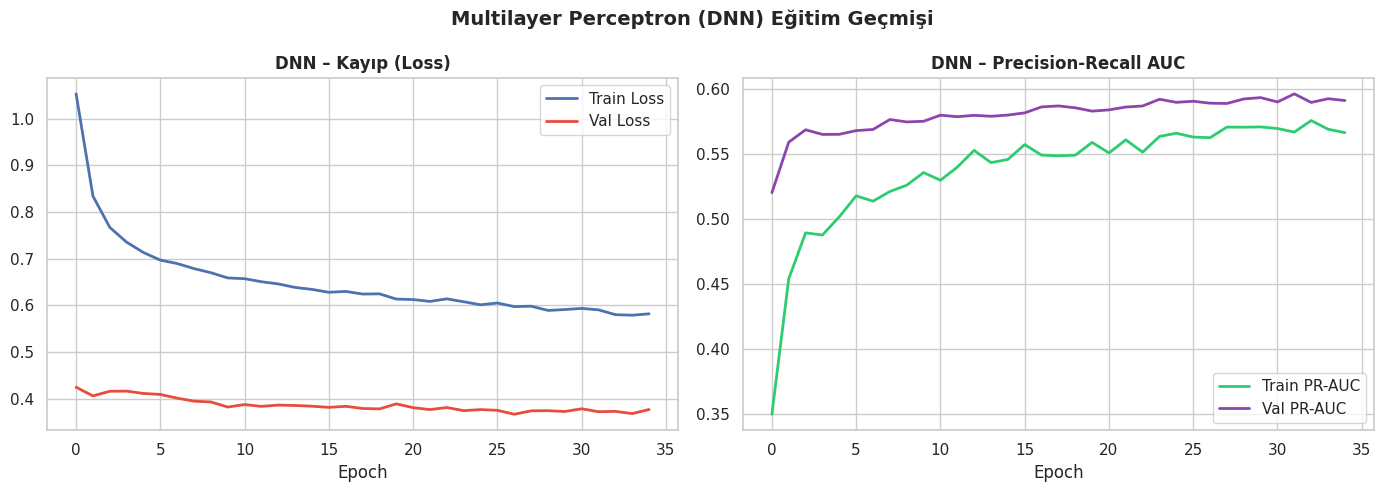

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print("\n── DERİN ÖĞRENME: ÇOK KATMANLI ALGILAYICI (DNN/MLP) ──\n")

# 1. Keras İçin Sınıf Ağırlıkları (Class Weights)
# Azınlık sınıfındaki (1) hatayı cezalandırmak için spw değerini kullanıyoruz
class_weights = {0: 1.0, 1: spw}

num_features = X_train_balanced.shape[1]
print(f"DNN Giriş Boyutu (Özellik Sayısı): {num_features}")

def build_dnn_model(input_dim):
    model = Sequential([
        Dense(128, activation="relu", input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    # Accuracy yerine F1 ve Dengesiz Veri dostu metrikleri (PR-AUC) ekledik
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc") # Precision-Recall AUC!
        ]
    )
    return model

dnn_model  = build_dnn_model(num_features)

# Aşırı öğrenmeyi engellemek için kayıp (loss) değerini takip ediyoruz
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

print("\nDNN Eğitimi Başlıyor...")
history = dnn_model.fit(
    X_train_balanced, y_train_balanced,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weights,  # <--- SMOTE YERİNE BU PARAMETRE HAYAT KURTARIR
    callbacks=[early_stop],
    verbose=1
)

# 2. Keras Modeline Özel Optimum Eşik (Threshold) Bulma İşlemi
print("\nDNN İçin Optimum Eşik Değeri Hesaplanıyor...")
train_probs = dnn_model.predict(X_train_balanced, verbose=0).ravel()
precisions, recalls, thresholds = precision_recall_curve(y_train_balanced, train_probs)

# F1 skorunu maksimize eden eşiği bul
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
best_dnn_thresh = thresholds[optimal_idx]

print(f"✔ Eğitim Setinden Bulunan Optimum DNN Eşiği: {best_dnn_thresh:.4f}")

# 3. Test Seti Değerlendirmesi
dnn_probs = dnn_model.predict(X_test_scaled, verbose=0).ravel()
dnn_preds = (dnn_probs >= best_dnn_thresh).astype(int)

print("\n[Gerçek] DNN Test Seti Performansı:")
print(classification_report(y_test, dnn_preds))

# Karşılaştırma listesine eklemek için DNN sonuçları
dnn_metrics = {
    "Model":     "Deep Neural Network (DNN)",
    "Accuracy":  accuracy_score(y_test, dnn_preds),
    "Precision": precision_score(y_test, dnn_preds, zero_division=0),
    "Recall":    recall_score(y_test, dnn_preds, zero_division=0),
    "F1":        f1_score(y_test, dnn_preds, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, dnn_probs)
}

# 4. DNN Eğitim Grafikleri (Accuracy yerine PR-AUC ve Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Kayıp (Loss) Grafiği
ax1.plot(history.history["loss"],     label="Train Loss", lw=2, color="#4C72B0")
ax1.plot(history.history["val_loss"], label="Val Loss",   lw=2, color="#E74C3C")
ax1.set_title("DNN – Kayıp (Loss)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.legend()

# PR-AUC Grafiği
ax2.plot(history.history["pr_auc"],     label="Train PR-AUC", lw=2, color="#2ECC71")
ax2.plot(history.history["val_pr_auc"], label="Val PR-AUC",   lw=2, color="#8E44AD")
ax2.set_title("DNN – Precision-Recall AUC", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.legend()

plt.suptitle("Multilayer Perceptron (DNN) Eğitim Geçmişi", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
 #BOYUT İNDİRGEME (PCA) VE XGBOOST
pca_transformer = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca_transformer.fit_transform(X_train_balanced)
X_test_pca  = pca_transformer.transform(X_test_scaled)

pca_xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
pca_xgb_model.fit(X_train_pca, y_train_balanced)

pca_preds = pca_xgb_model.predict(X_test_pca)
pca_probs = pca_xgb_model.predict_proba(X_test_pca)[:, 1]

pca_metrics = {
    "Model":     "XGBoost + PCA",
    "Accuracy":  accuracy_score(y_test, pca_preds),
    "Precision": precision_score(y_test, pca_preds, zero_division=0),
    "Recall":    recall_score(y_test, pca_preds, zero_division=0),
    "F1":        f1_score(y_test, pca_preds, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, pca_probs),
    "probs": pca_probs, "preds": pca_preds
}
print(f"✔ XGBoost + PCA          | Acc: {pca_metrics['Accuracy']:.4f} | F1: {pca_metrics['F1']:.4f} | AUC: {pca_metrics['ROC-AUC']:.4f}")

✔ XGBoost + PCA          | Acc: 0.8977 | F1: 0.4523 | AUC: 0.9069


In [ ]:
# Önce eksik olabilecek metrik sözlüklerini manuel olarak oluşturuyoruz
# Not: lgb_tuned_probs, xgb_tuned_probs vb. değişkenlerin yukarıdaki hücrelerde oluşmuş olması gerekir.

all_metrics_list = []

# 1. Temel Modeller (Döngüden gelen model_results listesi)
all_metrics_list.extend(model_results)

# 2. Stacked Ensemble Metrikleri
stacked_metrics_final = {
    "Model": "Stacked Ensemble",
    "Accuracy": accuracy_score(y_test, stacked_preds),
    "Precision": precision_score(y_test, stacked_preds, zero_division=0),
    "Recall": recall_score(y_test, stacked_preds, zero_division=0),
    "F1": f1_score(y_test, stacked_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, stacked_probs),
    "probs": stacked_probs, "preds": stacked_preds
}
all_metrics_list.append(stacked_metrics_final)

# 3. DNN Metrikleri (Zaten dnn_metrics olarak yukarıda oluşturmuştuk ama garantiye alalım)
if 'dnn_metrics' in locals():
    all_metrics_list.append(dnn_metrics)

# 4. PCA Metrikleri (Eğer PCA hücresini çalıştırdıysanız ekler)
if 'pca_metrics' in locals():
    all_metrics_list.append(pca_metrics)

# DataFrame Oluşturma
final_results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ["probs", "preds"]} for r in all_metrics_list]
).set_index("Model").sort_values("ROC-AUC", ascending=False)

best_model_name = final_results_df["ROC-AUC"].idxmax()

print("✔ Tüm modeller başarıyla birleştirildi!")
display(final_results_df)

✔ Tüm modeller başarıyla birleştirildi!


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
LightGBM,0.902687,0.622253,0.428166,0.507279,0.924528
XGBoost,0.902577,0.622069,0.426276,0.505889,0.923868
Stacked Ensemble,0.885326,0.506583,0.763705,0.609122,0.923134
Deep Neural Network (DNN),0.880571,0.492866,0.718336,0.584615,0.914171
Random Forest,0.900254,0.740741,0.226843,0.347323,0.913720
XGBoost + PCA,0.897711,0.605388,0.361059,0.452339,0.906870
Logistic Regression,0.898927,0.625874,0.338374,0.439264,0.900036
SVM (Calibrated),0.898706,0.681122,0.252363,0.368276,0.894186
Decision Tree,0.895610,0.582849,0.379017,0.459336,0.855593


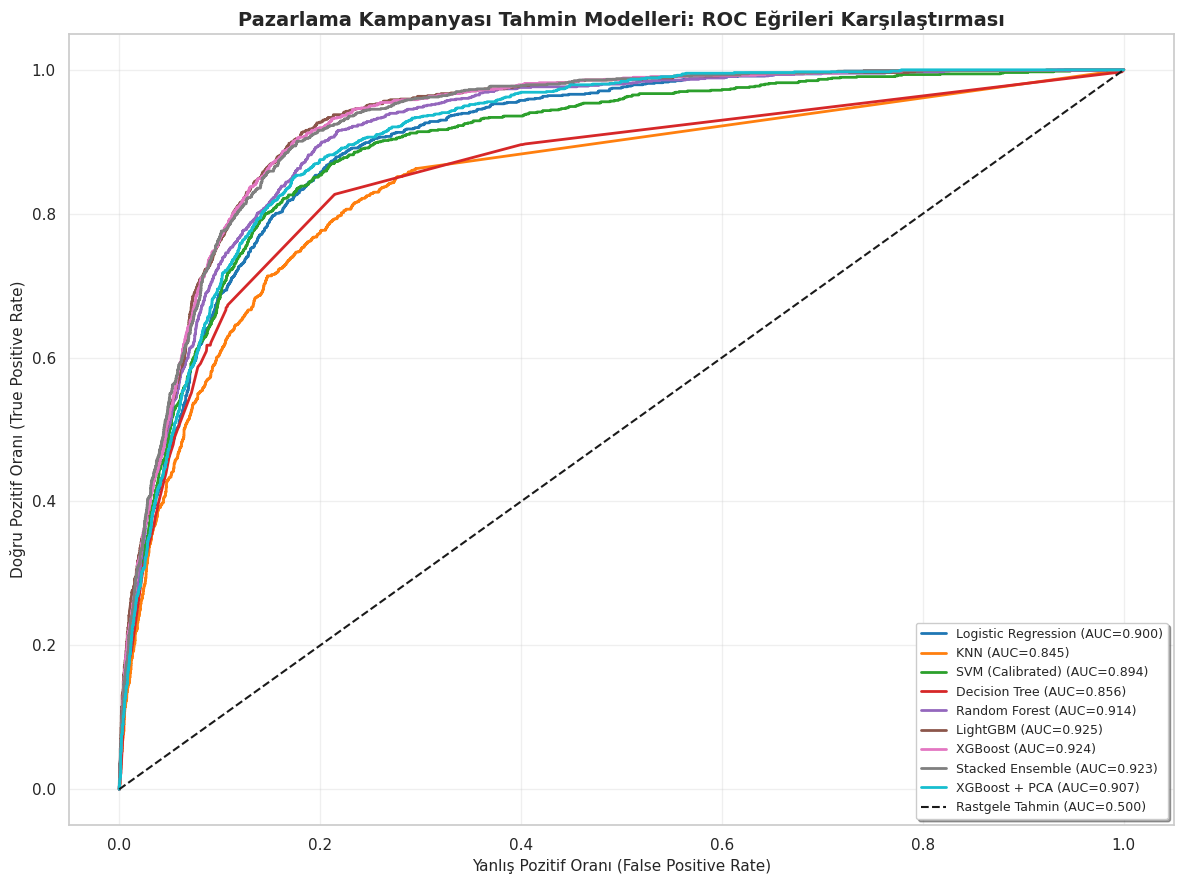

In [ ]:
from sklearn.metrics import roc_curve

# --- FİNAL ROC EĞRİLERİ GÖRSELLEŞTİRMESİ ---
fig, ax = plt.subplots(figsize=(12, 9))

# Renk paletini toplam model sayısına göre ayarlıyoruz
colors_final = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(all_metrics_list)))

for res, color in zip(all_metrics_list, colors_final):
    # 'probs' anahtarının varlığını kontrol ederek hata oluşmasını engelliyoruz
    if "probs" in res:
        fpr, tpr, _ = roc_curve(y_test, res["probs"])
        ax.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})", lw=2, color=color)

# Referans çizgisi (Rastgele Tahmin)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Rastgele Tahmin (AUC=0.500)")

# Grafik Düzenlemeleri
ax.set_xlabel("Yanlış Pozitif Oranı (False Positive Rate)", fontsize=11)
ax.set_ylabel("Doğru Pozitif Oranı (True Positive Rate)", fontsize=11)
ax.set_title("Pazarlama Kampanyası Tahmin Modelleri: ROC Eğrileri Karşılaştırması", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=9, frameon=True, shadow=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

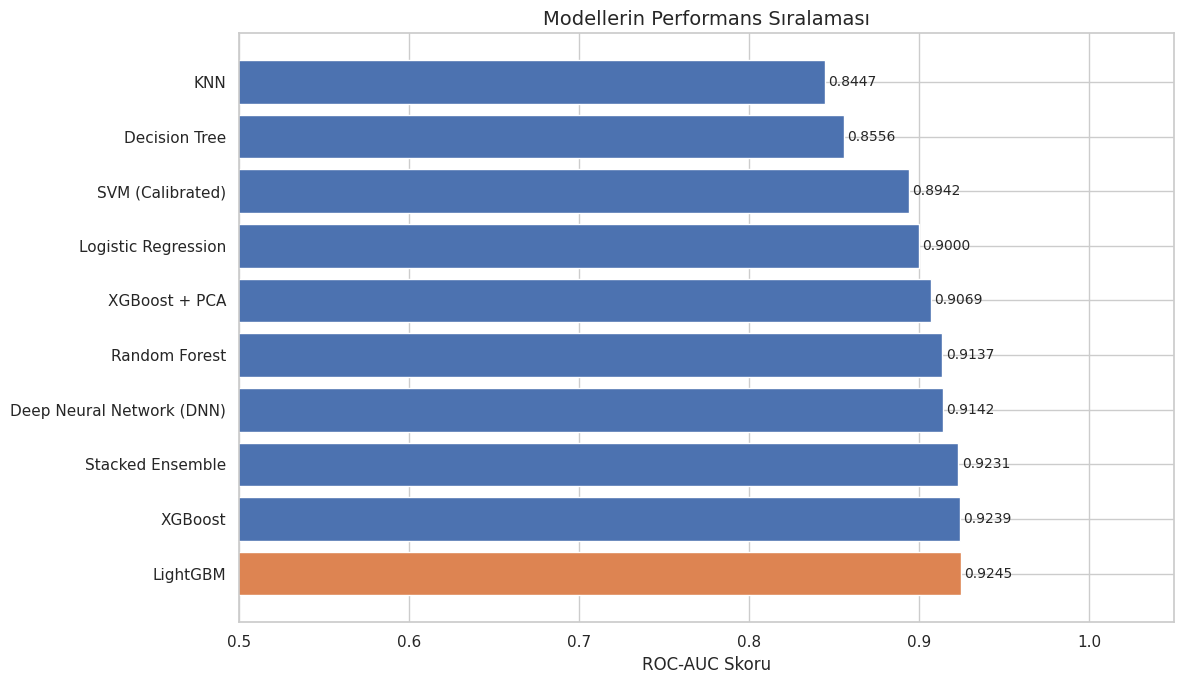

In [ ]:
#Bar Grafiği ile Modellerin ROC-AUC Karşılaştırması
fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#DD8452" if n == best_model_name else "#4C72B0" for n in final_results_df.index]
bars = ax.barh(final_results_df.index, final_results_df["ROC-AUC"], color=bar_colors, edgecolor="white")
for bar, val in zip(bars, final_results_df["ROC-AUC"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=10)
ax.set_xlim(0.5, 1.05); ax.set_xlabel("ROC-AUC Skoru", fontsize=12)
ax.set_title("Modellerin Performans Sıralaması", fontsize=14)
plt.tight_layout(); plt.show()

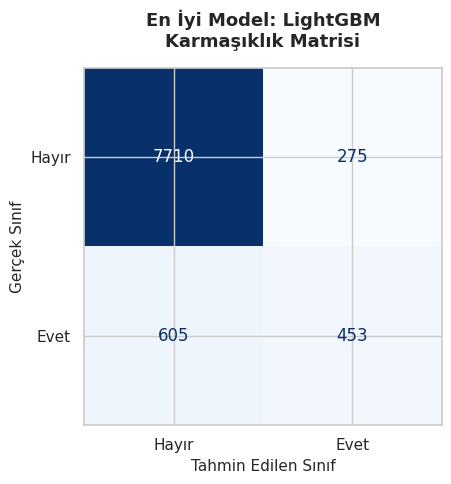

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- EN İYİ MODEL İÇİN KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) ---

# Listemizdeki ismi güncelleyerek en iyi modeli buluyoruz
try:
    best_res = next(r for r in all_metrics_list if r["Model"] == best_model_name)

    fig, ax = plt.subplots(figsize=(6, 5))

    # Karmaşıklık matrisini hesapla
    cm_best = confusion_matrix(y_test, best_res["preds"])

    # Görselleştirme
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Hayır", "Evet"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format='d')

    # Estetik dokunuşlar
    ax.set_title(f"En İyi Model: {best_model_name}\nKarmaşıklık Matrisi", fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("Tahmin Edilen Sınıf", fontsize=11)
    ax.set_ylabel("Gerçek Sınıf", fontsize=11)

    plt.tight_layout()
    plt.show()

except NameError:
    print("Hata: 'best_model_name' veya 'all_metrics_list' tanımlı değil. Lütfen önceki hücreleri çalıştırdığınızdan emin olun.")
except StopIteration:
    print(f"Hata: '{best_model_name}' model sonuçları arasında bulunamadı.")

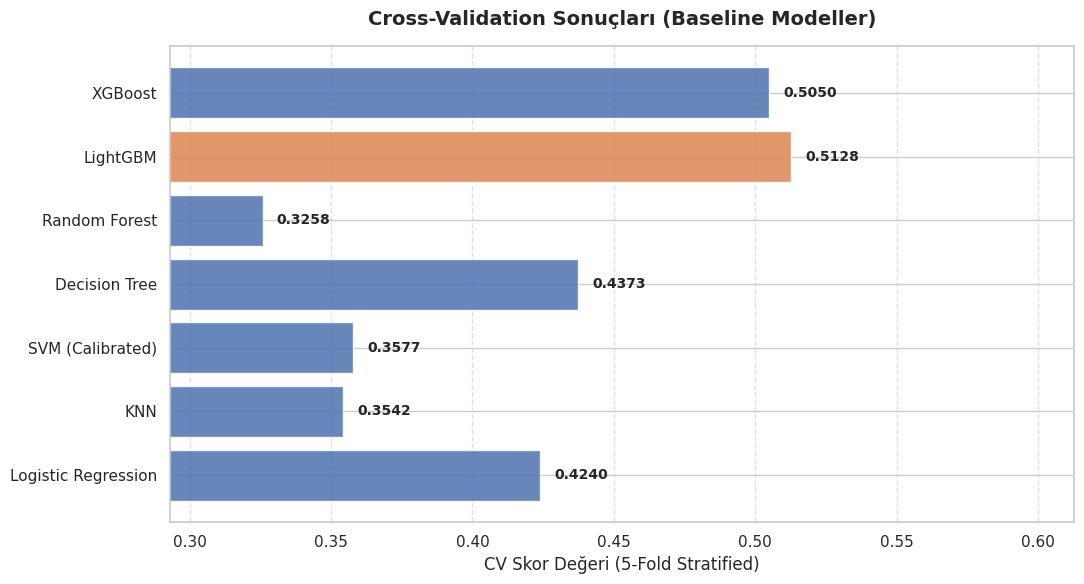

In [ ]:
# --- Cross-Validation Karşılaştırma Grafiği (Güncellenmiş) ---
if cv_scores:
    fig, ax = plt.subplots(figsize=(11, 6))

    cv_names  = list(cv_scores.keys())
    cv_values = list(cv_scores.values())

    # En yüksek skoru farklı renkle vurgula (Turuncu: En iyi, Mavi: Diğerleri)
    colors_cv = ["#DD8452" if v == max(cv_values) else "#4C72B0" for v in cv_values]

    bars_cv = ax.barh(cv_names, cv_values, color=colors_cv, edgecolor="white", alpha=0.85)

    # Barların ucuna değerleri yazdır
    for bar, val in zip(bars_cv, cv_values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=10, fontweight='bold')

    # X ekseni sınırlarını dinamik ayarla (Verilerin biraz altından başlasın)
    min_val = min(cv_values) * 0.9
    ax.set_xlim(min_val, max(cv_values) + 0.1)

    # Etiketleri güncelle (Artık F1 veya seçtiğiniz ana metriği yansıtmalı)
    ax.set_xlabel("CV Skor Değeri (5-Fold Stratified)", fontsize=12)
    ax.set_title("Cross-Validation Sonuçları (Baseline Modeller)", fontsize=14, fontweight='bold', pad=15)

    ax.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Hata: 'cv_scores' sözlüğü boş. Lütfen modelleri CV'den geçirdiğiniz hücreyi çalıştırın.")

─── İş Etkisi (Business Impact) Analizi: LightGBM (Optimize Edilmiş) ───
Hedef Kitle (Test Seti): 9,043 kişi
Yapılan Arama Sayısı: 1,514 kişi
Yakalanan Başarılı Satış: 779 / 1,058

Geleneksel Yöntem (Herkesi Ara) Kârı : 605,850 TL
Akıllı Model (LightGBM (Optimize Edilmiş)) Kârı       : 703,300 TL
Maksimum Potansiyel (Kusursuz Model) : 1,005,100 TL



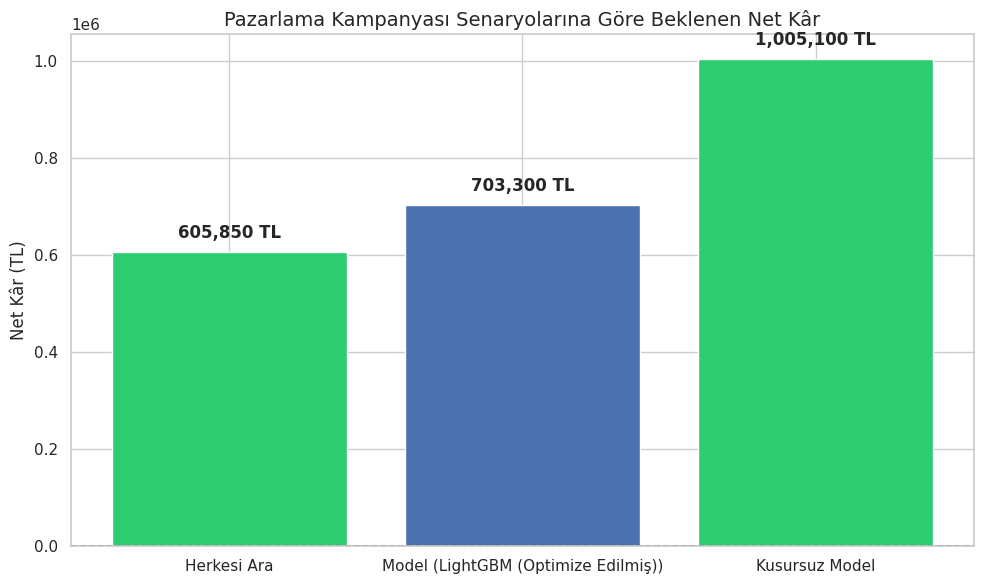

In [ ]:
# --- 7. İŞ ETKİSİ VE FİNANSAL KÂR / ZARAR ANALİZİ ---
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def calculate_business_impact(y_true, y_preds, model_name):
    # Karmaşıklık Matrisi (Confusion Matrix)
    tn, fp, fn, tp = confusion_matrix(y_true, y_preds).ravel()

    # Finansal Varsayımlar
    REVENUE_PER_SUCCESS = 1000  # Başarılı satış getirisi (TL)
    COST_PER_CALL = 50          # Arama maliyeti (TL)

    # Senaryo 1: Model Kullanımı (Sadece modelin '1' dediklerini ara)
    model_cost = (tp + fp) * COST_PER_CALL
    model_revenue = tp * REVENUE_PER_SUCCESS
    model_profit = model_revenue - model_cost

    # Senaryo 2: Herkesi Ara (Geleneksel körleme pazarlama)
    total_customers = len(y_true)
    total_actual_success = sum(y_true)

    all_call_cost = total_customers * COST_PER_CALL
    all_call_revenue = total_actual_success * REVENUE_PER_SUCCESS
    all_call_profit = all_call_revenue - all_call_cost

    # Senaryo 3: Mükemmel Model (Sadece gerçekten kabul edecekleri ara - Utopik senaryo)
    perfect_cost = total_actual_success * COST_PER_CALL
    perfect_revenue = total_actual_success * REVENUE_PER_SUCCESS
    perfect_profit = perfect_revenue - perfect_cost

    print(f"─── İş Etkisi (Business Impact) Analizi: {model_name} ───")
    print(f"Hedef Kitle (Test Seti): {total_customers:,} kişi")
    print(f"Yapılan Arama Sayısı: {tp + fp:,} kişi")
    print(f"Yakalanan Başarılı Satış: {tp:,} / {total_actual_success:,}\n")

    print(f"Geleneksel Yöntem (Herkesi Ara) Kârı : {all_call_profit:,.0f} TL")
    print(f"Akıllı Model ({model_name}) Kârı       : {model_profit:,.0f} TL")
    print(f"Maksimum Potansiyel (Kusursuz Model) : {perfect_profit:,.0f} TL\n")

    # Görselleştirme
    scenarios = ['Herkesi Ara', f'Model ({model_name})', 'Kusursuz Model']
    profits = [all_call_profit, model_profit, perfect_profit]

    plt.figure(figsize=(10, 6))
    colors = ['#E74C3C' if p < 0 else '#4C72B0' if p == model_profit else '#2ECC71' for p in profits]
    bars = plt.bar(scenarios, profits, color=colors)

    # Barların üzerine değerleri yaz
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(profits)*0.02),
                 f"{yval:,.0f} TL", ha='center', va='bottom', fontweight='bold')

    plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
    plt.title("Pazarlama Kampanyası Senaryolarına Göre Beklenen Net Kâr", fontsize=14)
    plt.ylabel("Net Kâr (TL)", fontsize=12)
    plt.tight_layout()
    plt.show()

# --- ANALİZİ ÇALIŞTIRMA ---
# Bir önceki adımda ürettiğimiz 'lgb_test_preds' (LightGBM tahminleri) kullanılıyor.
# Eğer XGBoost'u ana model seçmek isterseniz 'xgb_test_preds' yazabilirsiniz.
calculate_business_impact(y_test, lgb_test_preds, "LightGBM (Optimize Edilmiş)")

SHAP analizi için seçilen model: LightGBM
SHAP değerleri hesaplanıyor (TreeExplainer)...


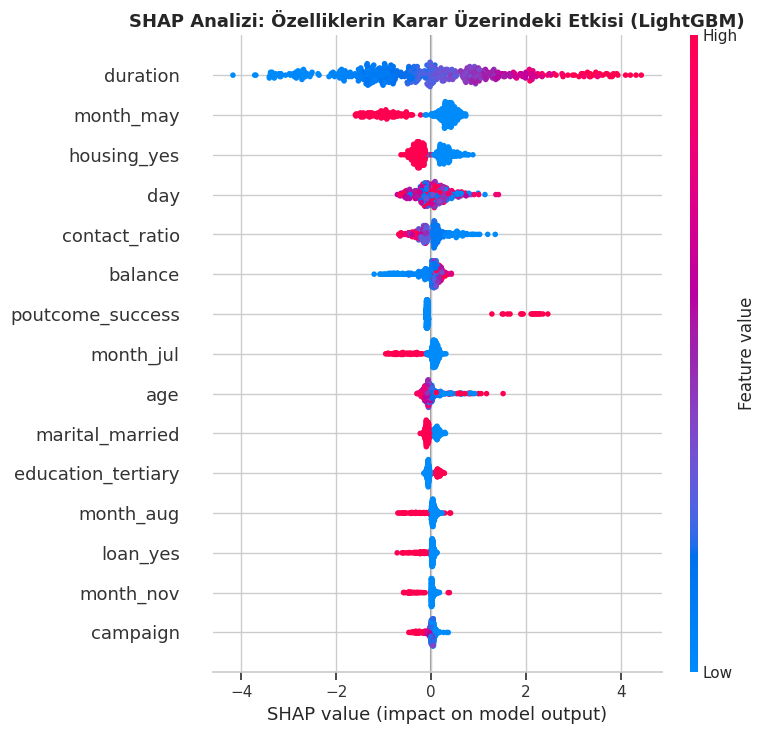

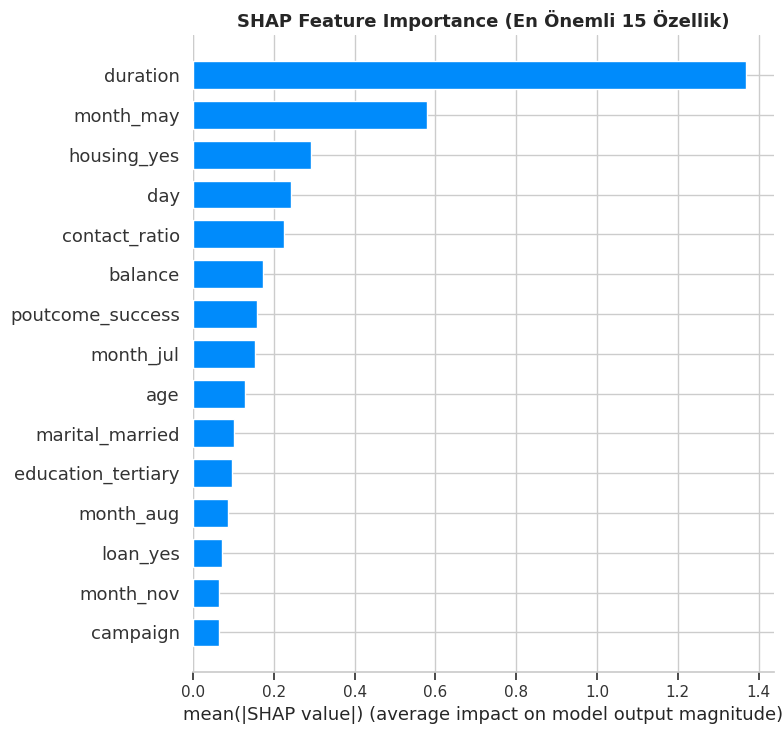

✔ SHAP analizi tamamlandı (LightGBM, 500 örnek).


In [ ]:
import shap

# --- 10. SHAP DEĞERLERİ İLE MODEL AÇIKLANABİLİRLİĞİ ---

# SHAP için en iyi tree-based modeli bul
feature_names = X_train_encoded.columns.tolist()
tree_candidates = ["LightGBM (Tuned)", "XGBoost (Tuned)", "LightGBM", "XGBoost", "Random Forest"]
shap_model_name = next((n for n in final_results_df.index if n in tree_candidates), None)

# Sütun isimlerini belirle (X_train_encoded DataFrame olduğu için sütun isimlerini oradan alıyoruz)
# Eğer bu kod hata verirse 'feature_names = X_train_encoded.columns.tolist()' satırını kontrol edin.
current_feature_names = X_train_encoded.columns.tolist()

if shap_model_name:
    # Modeli base_models içinden veya tuner'dan çekiyoruz
    if shap_model_name in base_models:
        shap_model = base_models[shap_model_name]
    elif "best_lgb" in locals() and "LightGBM" in shap_model_name:
        shap_model = best_lgb
    elif "best_xgb" in locals() and "XGBoost" in shap_model_name:
        shap_model = best_xgb
    else:
        shap_model = None

if shap_model:
    print(f"SHAP analizi için seçilen model: {shap_model_name}")
    print("SHAP değerleri hesaplanıyor (TreeExplainer)...")

    # Test setinden örnek al (Hız için 500 yeterlidir)
    sample_size = min(500, X_test_scaled.shape[0])
    X_shap = X_test_scaled[:sample_size]

    # Explainer oluşturma
    explainer = shap.TreeExplainer(shap_model)

    # SHAP değerlerini hesapla
    # Bazı versiyonlarda 'check_additivity=False' gerekebilir
    shap_results = explainer(X_shap, check_additivity=False)

    # SHAP değerlerini çekme (Sınıf 1 - Pozitif Sınıf için)
    # Yeni SHAP versiyonlarında (>= 0.36) sonuçlar .values içinde 3 boyutlu olabilir
    if len(shap_results.values.shape) == 3:
        # [örnek_sayısı, özellik_sayısı, sınıf_sayısı] yapısında ise Sınıf 1'i (Abone) seç
        shap_vals = shap_results.values[:, :, 1]
    else:
        shap_vals = shap_results.values

    # ── 10.1 SHAP Summary Plot (Beeswarm) ──
    plt.figure(figsize=(11, 8))
    # 'feature_names' parametresi X_shap bir numpy array olduğu için kritik öneme sahip
    shap.summary_plot(
        shap_vals,
        X_shap,
        feature_names=current_feature_names,
        max_display=15,
        show=False
    )
    plt.title(f"SHAP Analizi: Özelliklerin Karar Üzerindeki Etkisi ({shap_model_name})", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── 10.2 SHAP Feature Importance (Bar) ──
    plt.figure(figsize=(11, 6))
    shap.summary_plot(
        shap_vals,
        X_shap,
        feature_names=current_feature_names,
        plot_type="bar",
        max_display=15,
        show=False
    )
    plt.title(f"SHAP Feature Importance (En Önemli 15 Özellik)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"✔ SHAP analizi tamamlandı ({shap_model_name}, {sample_size} örnek).")
else:
    print(" Uygun tree-based model bulunamadı veya model henüz eğitilmedi, SHAP atlanıyor.")